***
# Homework 6: numpy, scipy and matplotlib

**Course:** STAT 606 - Computing in Data Science and Statistics SP24

**Name:** Shrivats Sudhir

**NetID:** ssudhir2

**Email:** ssudhir2@wisc.edu

**Collaborators:** Samuel Merten.

**Date:** March 8th, 2024
***

In [1]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt

## 1.) Warmup: Around the Semicircular Law (3 points, spent $\approx$ 40 minutes)

**The (comparatively) young field of random matrix theory (RMT) concerns the behavior of certain matrices with independent random entries. A landmark result in RMT concerns the behavior of the eigenvalues of a random symmetric matrix with normal entries. Under the proper scaling, the joint distribution of the eigenvalues of such a matrix follows the *Wigner semicircular distribution*, which has density**

$$ f(x) = 
\begin{cases} 
\frac{\sqrt{4 - x^2}}{2\pi} & \text{If}\;-2 \le x \le 2\\
0 & \text{Otherwise}
\end{cases} \quad \quad (1)$$

**That is, a symmetric matrix with random normal entries will have eigenvalues whose histogram looks more and more like a semicircle of radius $2$ as n increases to $\infty$. In particular, define a matrix-valued random variable $Z \in \mathbb{R}^{n \times n}$ by generating $Z_{ij}$ iid normal with mean $0$ and variance $\frac{1}{n}$ for all $1 \le i \le j \le n$, and set $Z_{ji} = Z_{ij}$ for $1 \le j \le i \le n$. Then the matrix $Z \in \mathbb{R}^{n \times n}$ is called a *Wigner matrix*.**

**Define a function `wigner_density` that takes a single number (integer or float) as its input and returns a float as its output, given by the value of the semicircular density evaluated at the input. That is, for a number $x$, `wigner_density(x)` should return $f(x)$, where $f$ is defined above in Equation (1). You do not need to perform any error checking in this function, but note that your function should operate equally well on Python ints/floats and on numpy ints/floats, and you should be able to accomplish this without checking the type of the input. Use the `numpy.sqrt` function for the square root, NOT the Python `math.sqrt` function.**

In [2]:
def wigner_density(x):
    '''
    function to calculate the Wigner semicircle density

    input
    x : int or float
        the value at which to calculate the density

    output
    f(x) : float
            sqrt(4 - x^2) / (2 * pi) if -2 <= x <= 2
            0 otherwise
    '''
    if -2 <= x and x <= 2:
        return np.sqrt(4 - x**2) / (2 * (np.pi))
    else:
        return 0

**Define a function `generate_wigner` that takes a single positive integer `n` as its argument and returns a random $n$-by-$n$ Wigner matrix. Your function should raise an appropriate error in the event that the input is not a positive integer. The output of your function may be either a `numpy` matrix or simply a `numpy` array, though I would recommend the former, for ease of use in the next sub-problem. You can cast a 2-dimensional `numpy` array a to a matrix by writing `np.matrix(a)`.** 

**Hint: depending on the solution you choose, you may find the `numpy.triu` and `numpy.tril` functions to be useful. A different solution makes use of the `scipy.spatial.distance.squareform` function.**

In [3]:
def generate_wigner(n):
    '''
    function to generate a Wigner matrix of size n-by-n

    n : int
        the size of the Wigner matrix

    output
    Z : numpy.ndarray
        the Wigner matrix of size n-by-n
    '''

    if not isinstance(n, (int, )):
        raise TypeError(f'n = {n} must be of type int.') # raises error when n is not of type int.
    if n <= 0:
        raise ValueError(f'n = {n} must be a positive integer.') # raises error when n is not a positive integer.
    
    Z = np.zeros((n, n)) # np.zeros((n, n)) gives us a (n-by-n) 2-dimensional numpy array of zeros.
    
    for i in range(n): # iterate over the rows of the matrix
        for j in range(i, n): # iterate over the columns of the matrix
            sample = np.random.default_rng().normal(loc = 0, scale = 1/n, size = 1) # get a single sample from a normal distribution
            Z[i, j] = sample[0] # set row i, column j to the sample
            Z[j, i] = sample[0] # set row j, column i to the sample
            
    return Z

**The RMT result referenced above states that the joint distribution of the eigenvalues of a random Wigner matrix converges to the semicircular law. Write a function `get_spectrum` that takes a numpy matrix or 2-dimensional numpy array and returns a numpy array of its eigenvalues in *non-decreasing* order. You do not need to perform any error checking for this function.**

In [4]:
def get_spectrum(Z):
    '''
    function to calculate the eigenvalues of Wigner matrix

    input
    Z : numpy.ndarray
        the Wigner matrix of size n-by-n

    output
    eigenvalues : numpy.ndarray
                  the eigenvalues of Z
    '''
    eigenvalues = np.sort(np.linalg.eigh(Z)[0])
    return eigenvalues

def scale_wigner_eigenvalue(eigenvalues, upper, lower):
    '''
    function to scale eigenvalues of Wigner matrix to a given range 

    inputs
    eigenvalues : numpy.ndarray
                  the eigenvalues of Wigner matrix

    upper : int or float
            the upper limit of the range

    lower : int or float
            the lower limit of the range

    output
    scaled_eigenvalues : numpy.ndarray
                         the eigenvalues of Wigner matrix scaled to the range [lower, upper]
    '''
    scaled_eigenvalues = []
    for x in eigenvalues:
        scaled_x = (x - min(eigenvalues)) / (max(eigenvalues) - min(eigenvalues)) * (upper - lower) + lower
        scaled_eigenvalues.append(scaled_x)
    return scaled_eigenvalues

**Create a plot with four subplots, arranged vertically, each showing a (normalized) histogram, in blue, of the eigenvalues of a random $n$-by-$n$ Wigner matrix for $n = 100, 200, 500$ and $1000$. In each subplot, overlay a red curve indicating the density of the semicircular law, as defined in (1). Save this plot in a `.png` file called `wigner_plots.png` and include it in your submission.**

**Hint: depending on how you implemented wigner_density above, you may find the numpy.vectorize function helpful.**

In [5]:
def wigner_plot(arr, scaled_wigner_eigenvalue, x, y):
    '''
    function to plot the histogram of eigenvalues of Wigner matrix

    inputs
    arr : list
          the list of sizes (n) of Wigner matrix

    scaled_wigner_eigenvalue : list
                               the list of eigenvalues of Wigner matrix scaled to the range [-2, 2]

    x : numpy.ndarray
        the x values for the Wigner semicircle density

    y : numpy.ndarray
        the y values for the Wigner semicircle density
    '''
    fig, axs = plt.subplots(len(arr), figsize = (7, 15))

    for i in range(len(arr)):
        # plots the histogram of eigenvalues of Wigner matrix
        axs[i].hist(scaled_wigner_eigenvalue[i], 
                    density = True,
                    bins = 50,
                    color = 'blue',
                    edgecolor = 'black',
                    alpha = 1)
        
        # plots the Wigner semicircle density
        axs[i].plot(x, y, color = 'red', linewidth = 2)
        
        # sets the title, x-axis label, y-axis label, and x-axis limits
        axs[i].set_xlim([-2.5, 2.5])
        axs[i].set_title(f'{arr[i]}-by-{arr[i]} random wigner matrix')

    # sets the title of the figure and adjusts the space between the subplots
    fig.suptitle('Histogram for Eigenvalues of n-by-n Wigner Matrix.', y = 0.92)
    plt.subplots_adjust(hspace = 0.25)
    plt.show()

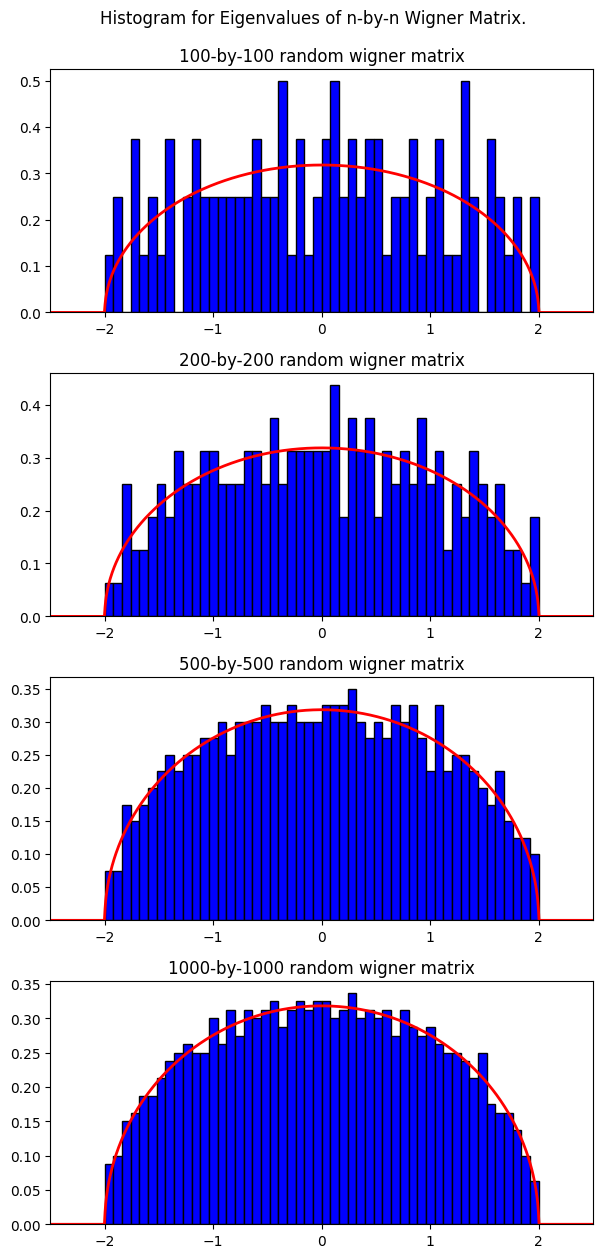

In [6]:
x = np.linspace(-3, 3, 1000) # generates 1000 evenly spaced values from -3 to 3
y = list(map(lambda xi: wigner_density(xi), x)) # calculates the Wigner semicircle density for each value in x

arr = [100, 200, 500, 1000] # list of sizes (n) of Wigner matrix
wigner_matrix = list(map(lambda n: generate_wigner(n), arr)) # list of Wigner matrices of size n-by-n
wigner_eigenvalues = list(map(lambda Z: get_spectrum(Z), wigner_matrix)) # list of eigenvalues of Wigner matrices
scaled_wigner_eigenvalue = list(map(lambda x: scale_wigner_eigenvalue(x, 2, -2), wigner_eigenvalues)) # list of eigenvalues of Wigner matrices scaled to the range [-2, 2]

wigner_plot(arr, scaled_wigner_eigenvalue, x , y)

**At least based on looking at the plots, how big does `n` have to be before the semicircular law appears to be a good fit? In practice, we would answer this question more rigorously with, for example, a Kolmogorov-Smirnov test, which you can find in the `scipy.stats` module, but that is entirely optional.**

**Note: this experiment involves some matrix eigenvalue computations, which are comparatively expensive. If you set n larger than about 5000, be prepared to wait a few minutes for your answer, especially if you are running on an older machine or on a VM.**

Looking at the above example, a 500-by-500 Wigner Matrix eigenvalues do seem to fit sufficiently well with the semicircular law. That said, for a $n > 500$, the corresponding n-by-n Wigner Matrix smoothens out the edges and gives us a very good approximation of the semicircular law. However, given the time it takes to run it, I believe a 500-by-500 should be sufficient.

Below is a plot to show what a 5000-by-5000 Wigner matrix would look like for reference.

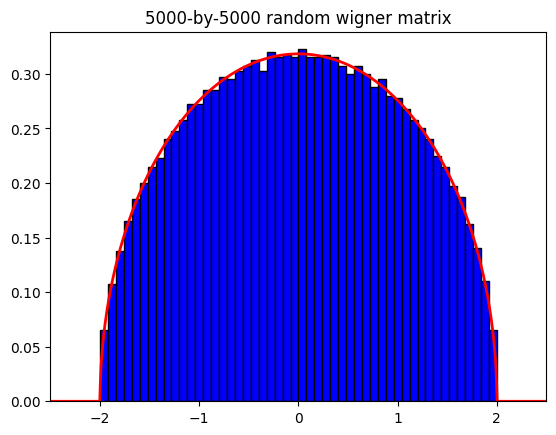

In [7]:
n = 5000
wigner_eigenvalue = get_spectrum( generate_wigner(n) )
scaled_wigner_eigenvalue = scale_wigner_eigenvalue(wigner_eigenvalue, 2, -2)

plt.hist(scaled_wigner_eigenvalue, 
         density = True,
         bins = 50,
         color = 'blue',
         edgecolor = 'black',
         alpha = 1)

plt.plot(x, y, color = 'red', linewidth = 2)  
      
plt.xlim([-2.5, 2.5])
plt.title(f'{n}-by-{n} random wigner matrix')

plt.show()

## 2.) Plotting a Mixture of Normals (3 points, spent $\approx$ 20 minutes)

**The whole reason that we use plotting software is to visualize the data that we are working with, so let’s do that. The zip file located at https://pages.stat.wisc.edu/~kdlevin/teaching/Spring2024/STAT606/hw/hw6_files.zip contains two files, storing data from a simulation experiment in my own research. The file `points.dlm` is a tab-delimited file (.dlm stands for “delimited”). Such a format is common when writing reasonably small files, and is useful if you expect to use a data set across different programs or platforms.**

**See the documentation for the command `numpy.loadtxt` to see how to read this file. The file `labels.npy` is a `numpy` binary file, representing a `numpy` object. The `.npy` file format is specific to `numpy`. Many languages (e.g., R and MATLAB) have their own such language-specific file formats for saving variables, workspaces, etc. These formats tend to be more space-efficient, typically at the cost of program-dependence. It is best to avoid such files if you expect to deal with the same data set in several different environments (e.g., you run experiments in MATLAB and do your statistical analysis in R). `.npy` files are opened using `numpy.load`.**

**The observations in my experiment were generated from a distribution that is *approximately* a mixture of normals, but not precisely so. Let’s explore how well the normal approximation holds.**

**Download the .zip file, extract it, and read the two files into `numpy`. Please include both `labels.npy` and `points.dlm` in your final submission. The former of these should yield a `numpy` array of 0s and 1s, and the latter should yield a 100-by-2 `numpy` array, in which each row corresponds to a 2-dimensional point. Each of these 2-dimensional points is assigned to one of two clusters. The i-th entry of the array in `labels.npy` encodes this the cluster membership label of the point in the i-th row of the matrix stored in `points.dlm`.**

In [8]:
labels = np.load('labels.npy')
points = np.loadtxt('points.dlm')
print(f'first 10 labels:\n{labels[0:10 - 1]}')
print('\n')
print(f'first 10 points:\n{points[0:10 - 1]}')

FileNotFoundError: [Errno 2] No such file or directory: 'labels.npy'

**Generate a scatter plot of the data. Each data point should appear as an x (often called a cross in data visualization packages), colored according to its cluster membership as given by `points.npy`. The points with cluster label 0 should be colored blue, and those with cluster label 1 should be colored red. Set the x- and y- axes to both range from 0 to 1. Adjust the size of the point markers to what you believe to be reasonable (i.e., aesthetically pleasing, visible, etc.).**

In [ ]:
def split_by_label(points, labels):
    '''
    function to split points by label 0 and 1

    inputs
    points : numpy.ndarray
             the points to be split
    
    labels : numpy.ndarray
             the labels to be used for splitting

    outputs
    zero_label_points : numpy.ndarray
                        the points with label 0
    
    one_label_points : numpy.ndarray
                       the points with label 1
    '''

    zero_label_points = np.zeros((0, 2)) # creates an empty numpy array of size (0, 2)
    one_label_points = np.zeros((0, 2)) # creates an empty numpy array of size (0, 2)

    for i in range(len(points)):
        if labels[i] == 0:
            zero_label_points = np.vstack(( zero_label_points, points[i] )) # adds the point to zero_label_points
        else:
            one_label_points = np.vstack(( one_label_points, points[i] )) # adds the point to one_label_points

    return zero_label_points, one_label_points

zero_label_points, one_label_points = split_by_label(points, labels)

In [ ]:
def scatter_plot():
    '''
    function to create a scatter plot of the points

    inputs
    None

    outputs
    fig : matplotlib.figure.Figure
          the figure object for the scatter plot
    '''
    fig, ax = plt.subplots()

    ax.scatter(zero_label_points[:, 0], 
               zero_label_points[:, 1], 
               marker = 'x',
               alpha = 0.8,
               color = 'blue', 
               label = '0')

    ax.scatter(one_label_points[:, 0], 
                one_label_points[:, 1], 
                marker = 'x',
                alpha = 0.8,
                color = 'red', 
                label = '1')

    ax.legend(loc = 'upper right')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    return fig, ax

In [ ]:
fig, ax = scatter_plot()
plt.show()

**Theoretically, the data should approximate a mixture of normals with means and covariance matrices given by**

$$ \mu_0 = (0.2, 0.7)^T, \quad \sum_0 = 
\begin{pmatrix} 
0.015 & -0.011\\
-0.011 & 0.018
\end{pmatrix} $$

$$ \mu_1 = (0.65, 0.3)^T, \quad \sum_0 = 
\begin{pmatrix} 
0.016 & -0.011\\
-0.011 & 0.016
\end{pmatrix} $$

**For each of these two normal distributions, add two contour lines corresponding to 1 and 2 “standard deviations” of the distribution. We will take the 1-standard deviation contour to be the level set (which is an ellipse) of the normal distribution that encloses probability mass 0.68 of the distribution, and the 2-standard deviation contour to be the level set that encloses probability mass 0.95 of the distribution.** 

**The contour lines for cluster 0 should be colored blue, and the lines for cluster 1 should be colored red. The contour lines might go off the edge of the 1-by-1 square that we have plotted. Do not worry about that.**

**Hint: these ellipses are really just confidence regions given by**

$$ (x - \mu)^T \sum^{-1} (x - \mu) \le \chi^2_2(p)$$

**where p is a probability and $\chi^2_d$ is the quantile function for the $\chi^2$ distribution with $d$ degrees of freedom.** 

**Hint: use the optional argument `levels` for the `pyplot.contour` function. The quantile function for the $\chi^2$ distribution is available in `scipy.stats.chi2`.**

In [ ]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html

mu_0 = np.array([0.2, 0.7]) # mean of the multivariate normal distribution for 0 label
cov_0 = np.array([[0.015, -0.011], [-0.011, 0.018]]) # covariance matrix of the multivariate normal distribution for 0 label
rv_0 = multivariate_normal(mu_0, cov_0) # multivariate random variable for 0 label

mu_1 = np.array([0.65, 0.3]) # mean of the multivariate normal distribution for 1 label
cov_1 = np.array([[0.016, -0.011], [-0.011, 0.016]]) # covariance matrix of the multivariate normal distribution for 1 label
rv_1 = multivariate_normal(mu_1, cov_1) # multivariate random variable for 1 label

x = np.linspace(0, 1, 1000) # generates 1000 evenly spaced values from 0 to 1
y = np.linspace(0, 1, 1000) # generates 1000 evenly spaced values from 0 to 1
X, Y = np.meshgrid(x, y) # creates a rectangular grid out of an array of x values and an array of y values
pos = np.dstack((X, Y)) # stacks the x and y values together

def contour_plot():
    '''
    function to create a contour plot of the points

    inputs
    None

    outputs
    fig : matplotlib.figure.Figure
          the figure object for the scatter plot + contour plot
    '''
    fig, ax = scatter_plot()

    ax.contour(x, y, rv_0.pdf(pos), alpha = 0.5, colors = 'blue')
    ax.contour(x, y, rv_1.pdf(pos), alpha  = 0.5, colors = 'red')

    return fig, ax

In [ ]:
fig, ax = contour_plot()
plt.show()

**Do the data appear normal? There should be at least one obvious outlier. Add an annotation to your figure indicating one or more such outlier(s).** 

**Note: as with many things in statistics, what does or does not constitute an outlier is ultimately a judgment call. There is not, strictly speaking, a right or wrong answer to this. Simply annotate your figure to indicate which points appear to you to be outliers**

In [ ]:
def detect_outlier(points, distribution, tolerance):
    '''
    function to detect outliers in the points

    inputs
    points : numpy.ndarray
             the points to be checked for outliers
    
    distribution : scipy.stats._multivariate.multivariate_normal_frozen object
                   the distribution to be used for checking

    tolerance : int or float
                the tolerance level for the distribution
    '''
    outliers = np.zeros((0, 2)) # creates an empty numpy array of size (0, 2)

    for point in points:
        # appends the point to outliers if the pdf of the distribution at the point is less than the tolerance
        if (distribution.pdf(point) < tolerance):
            outliers = np.vstack(( outliers, point ))
    return outliers

def annotate_outliers():
    '''
    function to annotate the outliers in the points

    inputs
    None

    outputs
    fig : matplotlib.figure.Figure
          the figure object for the scatter plot + contour plot + annotated outliers
    '''
    fig, ax = contour_plot()

    zero_label_outlier = detect_outlier(zero_label_points, rv_0, tolerance = 1.0)
    one_label_outlier = detect_outlier(one_label_points, rv_1, tolerance = 1.0)
    
    epsilon = 0.15
    for idx, zero_outlier in enumerate(zero_label_outlier):
        if idx % 2 == 0: # alternates the position of the arrow annotation
            ax.annotate('outlier', 
                        xy = (zero_outlier[0], zero_outlier[1]),
                        xytext = (zero_outlier[0] + epsilon, zero_outlier[1] + epsilon), # arrow anotates from the point to the right and above
                        arrowprops = dict(facecolor = 'black', shrink = 0.01),
                        horizontalalignment='left',
                        verticalalignment='bottom')
        else:
            ax.annotate('outlier', 
                        xy = (zero_outlier[0], zero_outlier[1]),
                        xytext = (zero_outlier[0] - epsilon, zero_outlier[1] - epsilon), # arrow anotates from the point to the left and below
                        arrowprops = dict(facecolor = 'black', shrink = 0.01),
                        horizontalalignment='left',
                        verticalalignment='bottom')

    # no alternating position for the arrow annotation as there are much fewer outliers
    for one_outlier in one_label_outlier:
        ax.annotate('outlier', 
                    xy = (one_outlier[0], one_outlier[1]),
                    xytext = (zero_outlier[0] + epsilon, zero_outlier[1] + epsilon), # arrow anotates from the point to the right and above
                    arrowprops = dict(facecolor = 'black', shrink = 0.01),
                    horizontalalignment='left',
                    verticalalignment='bottom')

    return fig, ax

In [ ]:
fig, ax = annotate_outliers()
plt.show()

Except for a couple of outliers (annotated above), the data appear to be sufficiently normal as most of the blue and red points lie within the contour pdfs of the multivariate normal distribution defined above.

## 3.) Conway's Game of Life (4 points, spent $\approx$ )

**Conway’s Game of Life is a classic example of a cellular automaton devised by mathematician John Conway. The game is a classic example of how simple rules can give rise to complex behavior. The game is played on an $m$-by-$n$ board, which we will represent as an $m$-by-$n$ matrix. The game proceeds in steps. At any given time, each cell of the board (i.e., entry of our matrix), is either alive (which we will represent by the Boolean `True`) or dead (which we will represent by the Boolean `False`). At each step, the board evolves according to a few simple rules:**

* **A live cell with fewer than two live neighbors becomes a dead cell.**

* **A live cell with more than three live neighbors becomes a dead cell.**

* **A live cell with two or three live neighbors remains alive.**

* **A dead cell with exactly three live neighbors becomes alive.**

* **All other dead cells remain dead.**

**The neighbors of a cell are the $8$ cells adjacent to it, i.e., left, right, above, below, upper left, lower-left, upper-right and lower-right. We will follow the convention that the board is toroidal, so that using matrix-like notation (i.e., the cell $(0,0)$ is in the upper-left of the board and the first coordinate specifies a row), the upper neighbor of the cell $(0,0)$ is $(m − 1,0)$, the right neighbor of the cell $(m − 1,n − 1)$ is $(m − 1,0)$, etc. That is, the board “wraps around”. This definition gets a bit odd when the board is smaller then three-by-three. You may simply ignore that case in what follows, if you wish. It will not be included when testing your code.**
 
**Note: you are not required to use this matrix-like indexing. It’s just what I chose to use to explain the toroidal property.**

**Write a function `is_valid_board` that takes a single argument and returns a Python Boolean that is `True` if and only if the argument is a valid representation of a Game of Life board. A valid board is any two-dimensional `numpy` `ndarray` whose entries are all numpy Booleans (i.e., `numpy.bool_`). Note that your function should accept, e.g., a two-by-two board as valid, even if the definition for generating the next step in such a board is a bit odd**

In [37]:
def is_valid_board(M):
    '''
    function to check if a given board is valid

    inputs
    M : numpy.ndarray
        the board to be checked

    outputs
    True : bool
           if the board is valid
    
    False : bool
            if the board is not valid
    '''
    if not M.shape[0] > 1:
        raise ValueError(f'Matrix must have at least 1 row.')
    
    if not M.shape[1] > 1:
        raise ValueError(f'Matrix must have at least 1 column.')

    return np.all(np.isin(M, [False, True]))
    

In [134]:
M = np.array([ [0,0,0,0,0],
               [0,0,1,0,0],
               [0,0,0,1,0],
               [0,1,1,1,0],
               [0,0,0,0,0] ])

is_valid_board(M)

True

**Write a function called `gol_step` that takes an $m$-by-$n$ `numpy` array as its argument and returns another `numpy` array of the same size (i.e., also $m$-by-$n$), corresponding to the board at the next step of the game. Your function should perform error checking to ensure that the provided argument is a valid Game of Life board.**

In [135]:
def neighbors(i, j, rows, cols):
    left = (i, (j - 1) % cols)
    right = (i, (j + 1) % cols)
    upper = ((i - 1) % rows, j)
    lower = ((i + 1) % rows, j)
    upper_right = ((i - 1) % rows, (j + 1) % cols)
    upper_left = ((i - 1) % rows, (j - 1) % cols)
    lower_right = ((i + 1) % rows, (j + 1) % cols)
    lower_left = ((i + 1) % rows, (j - 1) % cols)

    return [left, right, upper, lower, upper_right, lower_right, upper_left, lower_left]

def gol_step(M):

    if not is_valid_board(M):
        raise ValueError(f'Matrix must contain only boolean entries (1/0 or True/False).')
    
    rows = M.shape[0]
    cols = M.shape[1]
    
    for i in range(rows):
        for j in range(cols):

            tot_live = 0
            for neighbor in neighbors(i, j, rows, cols):
                if M[neighbor[0], neighbor[1]] == True:
                    tot_live += 1

    if M[i, j] == True:  # if the cell is alive
        if tot_live < 2 or tot_live > 3:  # if the cell has fewer than two or more than three live neighbors
            M[i, j] = False  # the cell becomes dead
        # if the cell has two or three live neighbors, it remains alive, so no need to change its state

    else:  # if the cell is dead
        if tot_live == 3:  # if the cell has exactly three live neighbors
            M[i, j] = True  # the cell becomes alive
        # if the cell has fewer than three or more than three live neighbors, it remains dead, so no need to change its state

    return M
            

**Write a function called `draw_gol_board` that takes an $m$-by-$n$ numpy array (i.e., an ndarray) as its only argument and draws the board as an $m$-by-$n$ set of tiles, colored black or white correspond to whether the corresponding cell is alive or dead, respectively. Your plot should not have any grid lines, nor should it have any axis labels or axis ticks.** 

**Hint: see the functions plt.xticks() and plt.yticks() for changing axis ticks.**

**Hint: you may find the function `plt.get_cmap` to be useful for working with the `matplotlib` `Colormap` objects.**

In [136]:
def draw_gol_board(M):
    cmap = plt.get_cmap('gray_r')
    plt.matshow(M, cmap = cmap)
    plt.axis('off')
    plt.show()

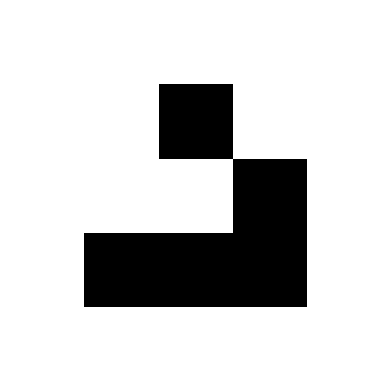

In [137]:
draw_gol_board(M)

**Create a $20$-by-$20$ numpy array corresponding to a Game of Life board in which all cells are dead, with the exception that the top-left $5$-by-$5$ section of the board looks like the above.**

**Plot this $20$-by-$20$ board using `draw_gol_board`, save this plot in `.png` file called `glider_board.png`, and include it in your submission.**

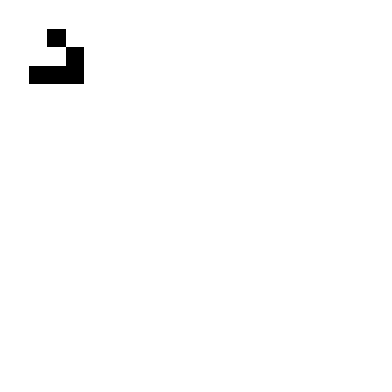

In [139]:
big_M = np.zeros((20, 20))

for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        big_M[i, j] = M[i, j]

draw_gol_board(big_M)

**Generate a plot with 5 subplots, arranged in a $5$-by-$1$ grid, showing the first five steps of the Game of Life when started with the board you just created, with the steps ordered from top to bottom. The first plot should be the starting board just described, so that the starting board is the first “step”. The figure in the $5$-by-$5$ sub-board above is called a glider, and it is interesting in that, as you can see from your plot, it seems to move along the board as you run the game. Save the resulting plot in a `.png` file called glider_5steps.png, and include it in your submission.**

In [142]:
def game_of_life_plot(n, initial_gol):
    '''
    function to plot the histogram of eigenvalues of Wigner matrix

    inputs
    n : int
        subplots and steps to take in the game of life board.

    outputs
    fig : matplotlib.figure.Figure
          the figure object for first n steps of gol board
    '''

    steps = [initial_gol]
    for i in range(1, n):
        steps.append(gol_step(steps[i-1]))

    for i in range(len(steps)):
        # plots the histogram of eigenvalues of Wigner matrix
        draw_gol_board(steps[i])
        
        plt.show()

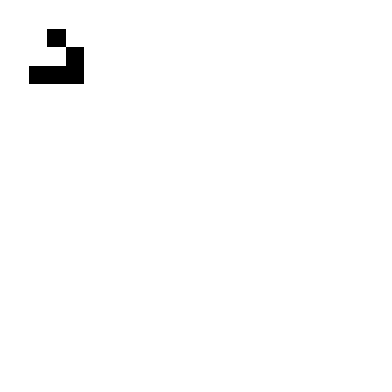

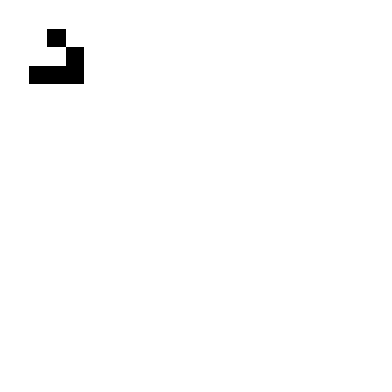

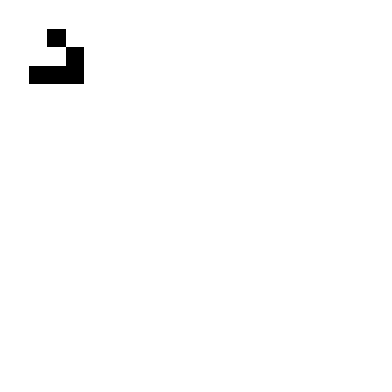

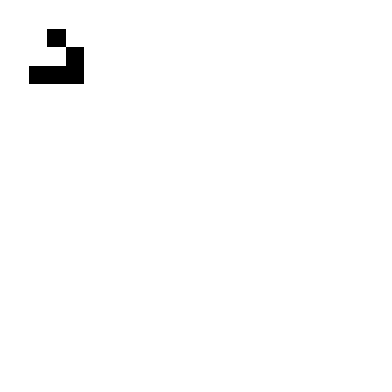

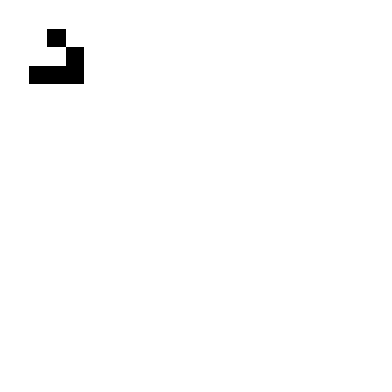

In [143]:
game_of_life_plot(5, big_M)